In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


In [4]:
df=pd.read_csv('../day_32/titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [7]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=0)
x_train

,Age,Fare,Family
140,NaN,15.2458,2
439,31.0,10.5000,0
817,31.0,37.0042,2
378,20.0,NaN,0
491,21.0,7.2500,0
...,...,...,...
835,39.0,83.1583,2
192,19.0,7.8542,1
629,NaN,7.7333,0
559,36.0,17.4000,1


In [8]:
mean_age=x_train['Age'].mean()
mean_fare=x_train['Fare'].mean()\

median_age=x_train['Age'].median()
median_fare=x_train['Fare'].median()

x_train['age_mean']=x_train['Age'].fillna(mean_age)
x_train['fare_mean']=x_train['Fare'].fillna(mean_fare)

x_train['age_median']=x_train['Age'].fillna(median_age)
x_train['fare_median']=x_train['Fare'].fillna(median_fare)

In [9]:
x_train.sample(10)

,Age,Fare,Family,age_mean,fare_mean,age_median,fare_median
667,NaN,7.7750,0,29.745184,7.7750,29.0,7.7750
482,50.0,8.0500,0,50.000000,8.0500,50.0,8.0500
888,NaN,23.4500,3,29.745184,23.4500,29.0,23.4500
124,54.0,77.2875,1,54.000000,77.2875,54.0,77.2875
770,24.0,9.5000,0,24.000000,9.5000,24.0,9.5000
134,25.0,13.0000,0,25.000000,13.0000,25.0,13.0000
84,17.0,10.5000,0,17.000000,10.5000,17.0,10.5000
282,16.0,9.5000,0,16.000000,9.5000,16.0,9.5000
0,22.0,7.2500,1,22.000000,7.2500,22.0,7.2500
441,20.0,9.5000,0,20.000000,9.5000,20.0,9.5000


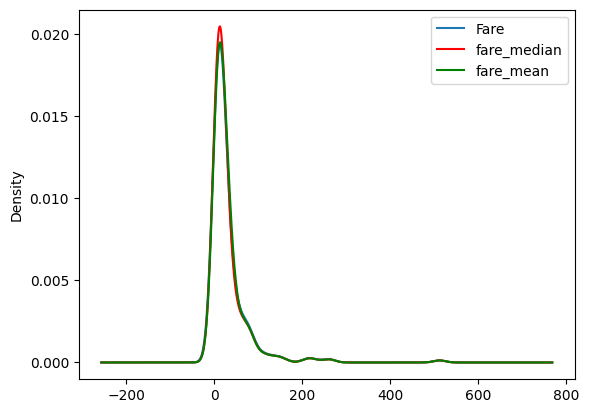

In [10]:
fig=plt.figure()
ax=fig.add_subplot(111)

x_train['Fare'].plot(kind='kde',ax=ax)
x_train['fare_median'].plot(kind='kde',ax=ax,color='red')
x_train['fare_mean'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')